In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn import metrics

In [2]:
df = pd.read_csv("../data/insurance-data.csv")
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


### structure et types de données

In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

## statistiques descriptives

In [4]:
display(df.describe())
display(df[["sex", "smoker", "region"]].describe())

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


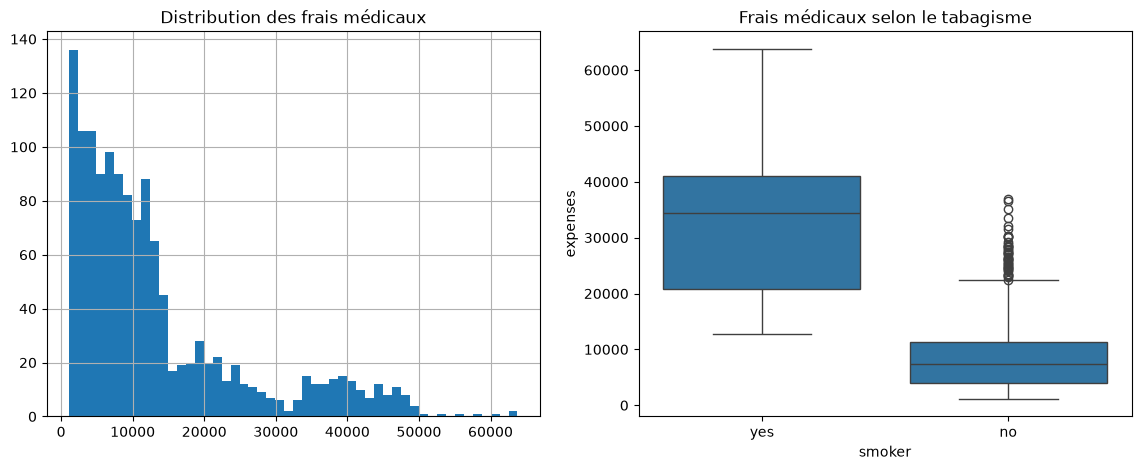

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["expenses"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution des frais médicaux")

sns.boxplot(data=df, x="smoker", y="expenses", ax=axes[1])
axes[1].set_title("Frais médicaux selon le tabagisme")
plt.show()

##  lien avec le BMI 

Le BMI (Body Mass Index, en français IMC = Indice de Masse Corporelle) est un indicateur qui évalue la corpulence d'une personne à partir de son poids et de sa taille :

 BMI = poids (kg) / taille² (m²)

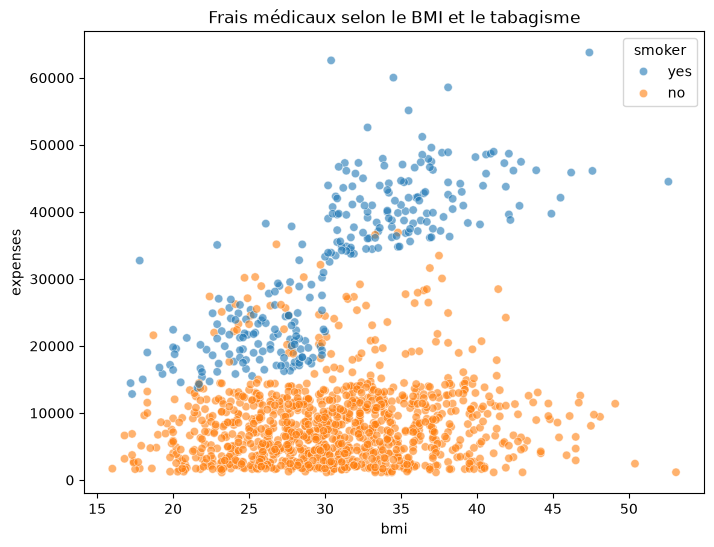

In [6]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="bmi", y="expenses", hue="smoker", alpha=0.6)
plt.title("Frais médicaux selon le BMI et le tabagisme")
plt.show()

Le tabagisme est le facteur qui augmente le plus les frais médicaux.
Son effet est encore amplifié en présence d'obésité (BMI ≥ 30) : les fumeurs obèses ont des frais nettement supérieurs aux fumeurs non-obèses,
suggérant une interaction entre ces deux facteurs plutôt qu'un simple effet additif.

## matrice de corrélation

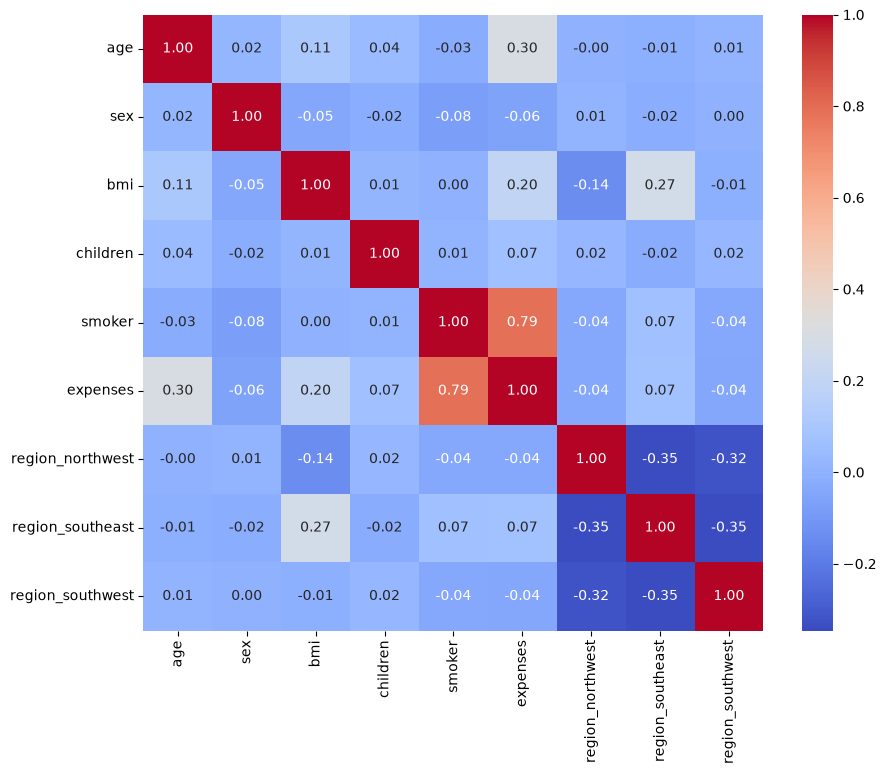

In [7]:
df_corr = df.copy()
df_corr["sex"] = df_corr["sex"].map({"male": 0, "female": 1})
df_corr["smoker"] = df_corr["smoker"].map({"no": 0, "yes": 1})
df_corr = pd.get_dummies(df_corr, columns=["region"], drop_first=True)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.show()

smoker domine très largement (corrélation 0.79 avec expenses), suivi de age (0.30) et bmi (0.20). children, sex et region ont un impact quasi négligeable.

 Ces résultats confirment l'observation métier attendue : le tabagisme est le principal moteur du coût des contrats d'assurance santé.

# Prétraitement 

# Split train/test

In [8]:
X = df.drop(columns=["expenses"])
y = df["expenses"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [10]:
print(X_train_processed.shape, X_test_processed.shape)

(1070, 8) (268, 8)


In [11]:
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_processed, y_train)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_processed, y_train)

knn = KNeighborsRegressor()
knn.fit(X_train_processed, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [12]:
models_pred_ins = {
    "LinearRegression": lr.predict(X_test_processed),
    "KNN": knn.predict(X_test_processed),
    "DecisionTree": tree.predict(X_test_processed),
    "RandomForest": rf.predict(X_test_processed)
}

results_ins = pd.DataFrame({
    "Modèle": list(models_pred_ins.keys()),
    "MSE": [metrics.mean_squared_error(y_test, p) for p in models_pred_ins.values()],
    "MAE": [metrics.mean_absolute_error(y_test, p) for p in models_pred_ins.values()],
    "R2": [metrics.r2_score(y_test, p) for p in models_pred_ins.values()]
}).sort_values(by="R2", ascending=False)

results_ins

,Modèle,MSE,MAE,R2
3,RandomForest,2.096390e+07,2563.473184,0.864966
0,LinearRegression,3.360007e+07,4181.561524,0.783573
2,DecisionTree,3.898037e+07,2971.415672,0.748917
1,KNN,4.676734e+07,3886.129575,0.698759


Comparaison des modèles :
 RandomForest est nettement le plus performant (R²=0.87, MAE=2556), devant LinearRegression, DecisionTree et KNN. On optimise donc ses hyperparamètres via GridSearchCV pour tenter d'améliorer encore ses performances.

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring="r2", n_jobs=-1)
grid_search.fit(X_train_processed, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur R² (validation croisée) :", grid_search.best_score_)

Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 100}
Meilleur R² (validation croisée) : 0.8414739642326274


In [14]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test_processed)

print("MSE :", metrics.mean_squared_error(y_test, y_pred_best_rf))
print("MAE :", metrics.mean_absolute_error(y_test, y_pred_best_rf))
print("R2 :", metrics.r2_score(y_test, y_pred_best_rf))

MSE : 19148573.187591545
MAE : 2488.360308680999
R2 : 0.8766587480110325


**Optimisation :** Le RandomForest optimisé (max_depth=10, min_samples_leaf=5, n_estimators=100) améliore légèrement les 3 métriques par rapport aux paramètres par défaut (R² : 0.865 → 0.877, MAE : 2556 → 2488), confirmant qu'une régularisation modérée limite le surapprentissage.

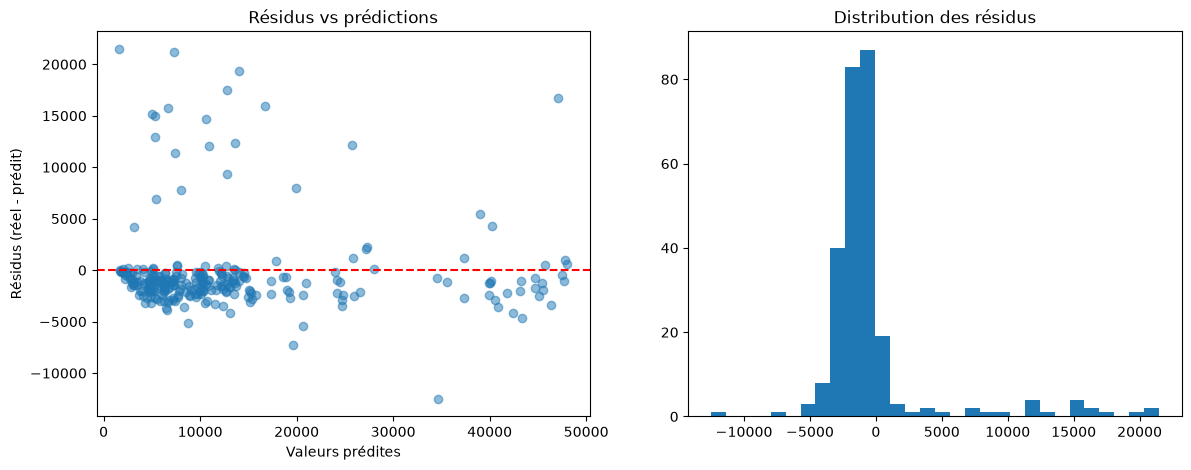

In [15]:
residuals = y_test - y_pred_best_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_best_rf, residuals, alpha=0.5)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valeurs prédites")
axes[0].set_ylabel("Résidus (réel - prédit)")
axes[0].set_title("Résidus vs prédictions")

axes[1].hist(residuals, bins=30)
axes[1].set_title("Distribution des résidus")
plt.show()

In [16]:
residuals_df = X_test.copy()
residuals_df["abs_residual"] = residuals.abs().values
residuals_df.groupby("smoker")["abs_residual"].mean()

smoker
no     2406.486662
yes    2812.822537
Name: abs_residual, dtype: float64

**Analyse des résidus :** Les erreurs sont globalement faibles et centrées autour de 0, mais le modèle sous-estime certains cas à coûts très élevés (résidus jusqu'à +20 000). L'erreur moyenne est plus élevée chez les fumeurs (2813 vs 2406), confirmant que ce sous-groupe — notamment l'interaction tabagisme/BMI élevé — reste le plus difficile à prédire précisément.

In [17]:
import joblib

joblib.dump(best_rf, "../model_rf.pkl")
joblib.dump(preprocessor, "../preprocessor.pkl")

['../preprocessor.pkl']

# Lot 1 : Tabagisme (Loïc)

**Question principale :** le tabagisme est-il le facteur qui influence le plus les frais médicaux, et de combien ?

**Sous-questions :**
1. La distribution globale des frais révèle-t-elle un sous-groupe à part (les fumeurs) ?
2. Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?
3. Ce surcoût est-il le même pour hommes et femmes ?

### KPI d'ouverture

In [18]:
cout_moyen = df["expenses"].mean()
cout_median = df["expenses"].median()
part_fumeurs = (df["smoker"] == "yes").mean()

print(f"Coût moyen du portefeuille  : {cout_moyen:,.0f} $")
print(f"Coût médian du portefeuille : {cout_median:,.0f} $")
print(f"Part de fumeurs             : {part_fumeurs:.1%}")

Coût moyen du portefeuille  : 13,270 $
Coût médian du portefeuille : 9,382 $
Part de fumeurs             : 20.5%


La moyenne (≈ 13 270 \$) est nettement au-dessus de la médiane (≈ 9 380 \$) : quelques assurés très coûteux tirent la moyenne vers le haut. La médiane décrit mieux l'assuré « typique », la moyenne reflète le coût réel à couvrir pour l'assureur.

### 1. La distribution globale des frais révèle-t-elle un sous-groupe à part ?

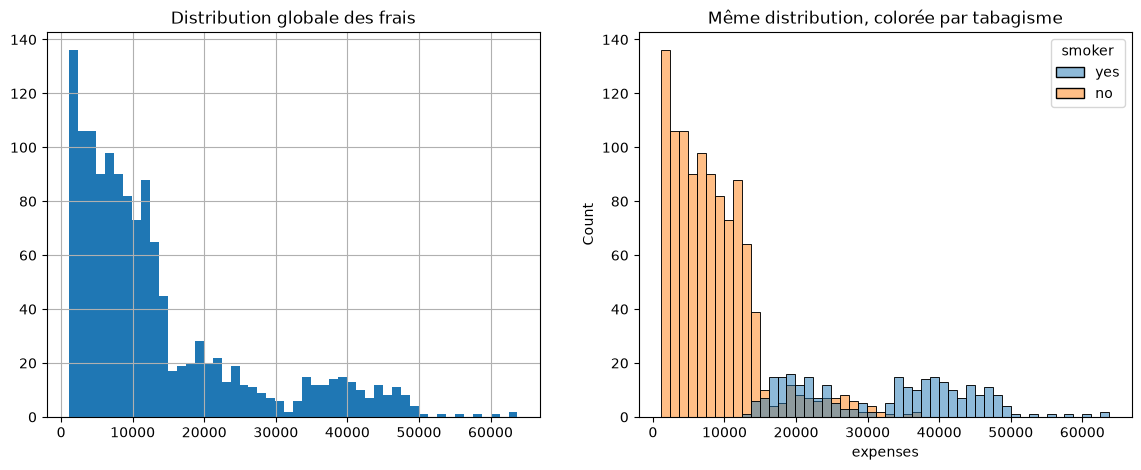

Assurés à plus de 30 000 $ : 162
dont fumeurs : 94%


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df["expenses"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution globale des frais")
sns.histplot(data=df, x="expenses", hue="smoker", bins=50, ax=axes[1])
axes[1].set_title("Même distribution, colorée par tabagisme")
plt.show()

# Qui sont les assurés les plus coûteux ?
gros_couts = df[df["expenses"] > 30000]
print(f"Assurés à plus de 30 000 $ : {len(gros_couts)}")
print(f"dont fumeurs : {(gros_couts['smoker'] == 'yes').mean():.0%}")

**Réponse :** oui. La distribution globale a une longue « queue » vers les frais élevés. En la colorant par tabagisme, on voit deux populations distinctes : les non-fumeurs sont concentrés sous ≈ 15 000 \$, tandis que les fumeurs forment un groupe à part, étalé de ≈ 15 000 à 60 000 \$. Sur les 162 assurés qui coûtent plus de 30 000 \$, **94 % sont fumeurs**.

### 2. Quel est l'écart de coût chiffré entre fumeurs et non-fumeurs ?

In [20]:
stats_tabac = df.groupby("smoker")["expenses"].agg(["count", "mean", "median"])
stats_tabac["part_des_assures"] = stats_tabac["count"] / len(df)
stats_tabac["part_des_depenses"] = df.groupby("smoker")["expenses"].sum() / df["expenses"].sum()
display(stats_tabac.round(2))

ratio = stats_tabac.loc["yes", "mean"] / stats_tabac.loc["no", "mean"]
print(f"Un fumeur coûte en moyenne {ratio:.1f} fois plus cher qu'un non-fumeur")

ecart_moyen = stats_tabac.loc["yes", "mean"] - stats_tabac.loc["no", "mean"]
ecart_median = stats_tabac.loc["yes", "median"] - stats_tabac.loc["no", "median"]
print(f"Écart de coût moyen  : +{ecart_moyen:,.0f} $ par fumeur")
print(f"Écart de coût médian : +{ecart_median:,.0f} $ par fumeur")

,count,mean,median,part_des_assures,part_des_depenses
smoker,,,,,
no,1064,8434.27,7345.40,0.8,0.51
yes,274,32050.23,34456.35,0.2,0.49


Un fumeur coûte en moyenne 3.8 fois plus cher qu'un non-fumeur
Écart de coût moyen  : +23,616 $ par fumeur
Écart de coût médian : +27,111 $ par fumeur


**Réponse :** un fumeur coûte en moyenne **32 050 \$** contre **8 434 \$** pour un non-fumeur, soit **+23 616 \$ (≈ 3,8 fois plus)**. En médiane, l'écart est encore plus grand : **+27 111 \$**. Les fumeurs ne représentent que **20 %** des assurés mais **49 %** des dépenses totales.

### 3. Ce surcoût est-il le même pour hommes et femmes ?

smoker,no,yes,surcout,ratio
sex,,,,
female,8762.3,30679.00,21916.7,3.50
male,8087.2,33042.01,24954.8,4.09


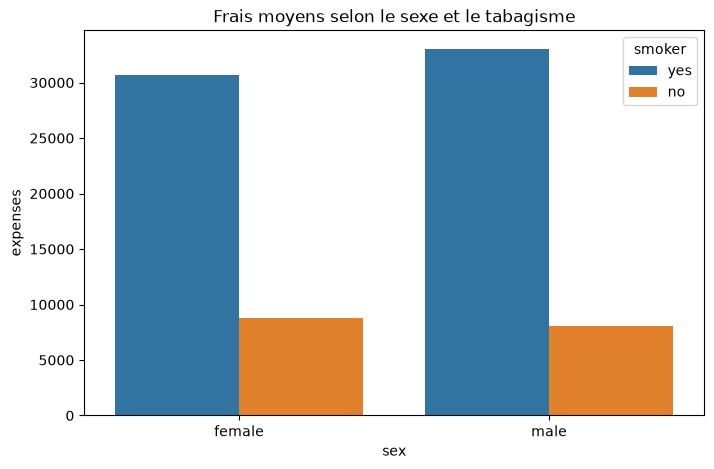

In [21]:
surcout_sexe = df.pivot_table(index="sex", columns="smoker", values="expenses", aggfunc="mean")
surcout_sexe["surcout"] = surcout_sexe["yes"] - surcout_sexe["no"]
surcout_sexe["ratio"] = surcout_sexe["yes"] / surcout_sexe["no"]
display(surcout_sexe.round(2))

plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="sex", y="expenses", hue="smoker", errorbar=None)
plt.title("Frais moyens selon le sexe et le tabagisme")
plt.show()

**Réponse :** le surcoût existe pour les deux sexes et il est du même ordre de grandeur : **+21 917 \$ (x3,5) chez les femmes** et **+24 955 \$ (x4,1) chez les hommes**. Il est un peu plus marqué chez les hommes (≈ 3 000 \$ de plus). Le sexe seul, en revanche, ne change presque rien : chez les non-fumeurs, femmes et hommes coûtent à peu près pareil (≈ 8 760 \$ contre 8 090 \$).

### Le tabagisme est-il le facteur n°1 ?

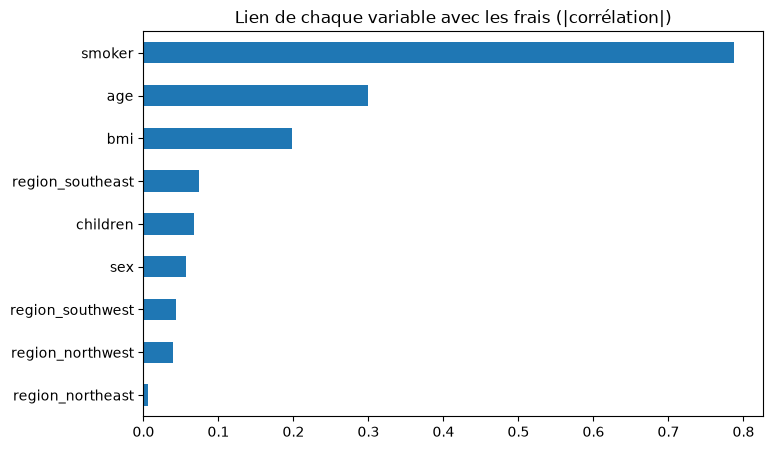

smoker              0.787
age                 0.299
bmi                 0.199
region_southeast    0.074
children            0.068
sex                 0.057
region_southwest    0.043
region_northwest    0.040
region_northeast    0.006
Name: expenses, dtype: float64

In [22]:
# Force du lien (corrélation, en valeur absolue) entre chaque variable et les frais
df_num = df.copy()
df_num["smoker"] = (df_num["smoker"] == "yes").astype(int)
df_num["sex"] = (df_num["sex"] == "male").astype(int)
df_num = pd.get_dummies(df_num, columns=["region"], dtype=int)

influence = df_num.corr()["expenses"].drop("expenses").abs().sort_values()
influence.plot(kind="barh", figsize=(8, 5), title="Lien de chaque variable avec les frais (|corrélation|)")
plt.show()
influence.sort_values(ascending=False).round(3)

**Conclusion du Lot 1 :**

**Oui, le tabagisme est de loin le facteur qui influence le plus les frais médicaux.** Sa corrélation avec les frais (0,79) est plus de 2,5 fois celle de l'âge (0,30), le 2e facteur, et 4 fois celle de l'IMC (0,20). Le sexe, le nombre d'enfants et la région pèsent très peu (< 0,08).

**De combien ?** Être fumeur ajoute en moyenne **≈ 23 600 \$** de frais par an (x3,8), pour les hommes comme pour les femmes. Les fumeurs forment un sous-groupe à part : 20 % des assurés, mais la moitié des dépenses et 94 % des assurés à plus de 30 000 \$.

➡️ Pour Aegis, le statut fumeur doit être le premier critère de tarification.